In [1]:
import subprocess, os, shutil

REPO_URL = "https://github.com/safety-research/legibility.git"
REPO_DIR = "/workspace/18-4-2026"
EXP_DIR = os.path.join(REPO_DIR, "experiments", "2026", "15-4-2026")

# Clone or pull latest (fetch + reset to ensure we have the newest commit)
if not os.path.exists(os.path.join(REPO_DIR, ".git")):
    subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)
else:
    subprocess.run(["git", "-C", REPO_DIR, "fetch", "origin"], check=True)
    subprocess.run(["git", "-C", REPO_DIR, "reset", "--hard", "origin/main"], check=True)

# Install git-lfs if not available, then pull LFS files
if shutil.which("git-lfs") is None:
    subprocess.run(["apt-get", "update", "-qq"], check=False)
    subprocess.run(["apt-get", "install", "-y", "-qq", "git-lfs"], check=False)
    subprocess.run(["git", "lfs", "install"], check=False)
subprocess.run(["git", "-C", REPO_DIR, "lfs", "pull"], check=False)

# Install dependencies
req_path = os.path.join(EXP_DIR, "requirements.txt")
if os.path.exists(req_path):
    subprocess.run(["pip", "install", "-q", "-r", req_path], check=True)
else:
    print(f"WARNING: {req_path} not found, skipping pip install")

# Set working directory so Path.cwd().parent resolves to experiment root
os.chdir(os.path.join(EXP_DIR, "notebooks"))

HEAD is now at 2ab22ca Add classification results for all 5 transform strategies


# NB7: Reader-Side Activation Analysis (Experiment D)

**CPU notebook** (~15 min). Analyzes R2 activations to understand what happens
inside the reader when it succeeds vs fails at C2 crossfill.

Split R2 activations by C2 outcome and legibility class. Train probe to predict
C2 success. Include foreignness covariate. Report AUROC with and without foreignness.

**Requires:** NB2 outputs (`activations/R2_last_token/`, `activations/R2_cot_boundary/`)

In [2]:
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

sys.path.insert(0, str(Path.cwd().parent))
from phase2_utils import (
    load_activations, load_foreignness_scores, train_binary_probe,
    permutation_test, plot_layer_probe_curve, bootstrap_ci_metric,
    ACTIVATIONS_DIR, PHASE2_RESULTS_DIR,
)

PHASE2_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
# Checkpoint: check if final output already exists
_output_path = PHASE2_RESULTS_DIR / 'reader_analysis_results.json'
if _output_path.exists():
    import json as _json
    with open(_output_path) as _f:
        _saved = _json.load(_f)
    print(f"CACHED: {_output_path} exists.")
    for key in _saved:
        n_layers = len(_saved[key]) if isinstance(_saved[key], dict) else 'N/A'
        print(f"  {key}: {n_layers} layers")
    print("Delete this file and re-run to recompute.")

CACHED: /workspace/18-4-2026/experiments/2026/15-4-2026/results/phase2/reader_analysis_results.json exists.
  c2_success_probe: 21 layers
  boundary_probe: 21 layers
  legibility_from_reader: 21 layers
Delete this file and re-run to recompute.


In [4]:
# Load R2 activations and metadata
r2_last = load_activations(ACTIVATIONS_DIR / "R2_last_token")
r2_boundary = load_activations(ACTIVATIONS_DIR / "R2_cot_boundary")

with open(ACTIVATIONS_DIR / "R2_last_token" / "metadata.json") as f:
    r2_meta = json.load(f)

r2_labels = np.array(r2_meta['labels'])  # 1=C2 success, 0=C2 failure
r2_sample_meta = r2_meta['sample_metadata']

print(f"R2 activations: {len(r2_labels)} samples, layers={sorted(r2_last.keys())}")
print(f"C2 success rate: {r2_labels.mean():.1%}")

# Check by legibility class
for label in ['ANSWER_LEAKED', 'REASONING_LEGIBLE', 'ILLEGIBLE']:
    mask = np.array([m['label'] == label for m in r2_sample_meta])
    if mask.sum() > 0:
        print(f"  {label}: n={mask.sum()}, C2 success={r2_labels[mask].mean():.1%}")

R2 activations: 666 samples, layers=[0, 4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 48, 52, 56, 60, 64, 68, 72, 76, 79]
C2 success rate: 51.4%
  ANSWER_LEAKED: n=278, C2 success=73.7%
  REASONING_LEGIBLE: n=100, C2 success=78.0%
  ILLEGIBLE: n=288, C2 success=20.5%


=== Probe: Predict C2 Success (excluding ANSWER_LEAKED) ===
Non-leaked samples: 388 (C2 success=137, failure=251)
  Layer   0: AUROC=0.500 CI=(0.5, 0.5)
  Layer   4: AUROC=0.576 CI=(0.5418412698412698, 0.6086257910571635)
  Layer   8: AUROC=0.601 CI=(0.5731164021164021, 0.63039070442992)
  Layer  12: AUROC=0.610 CI=(0.5983913683992116, 0.6234603174603174)
  Layer  16: AUROC=0.609 CI=(0.5814117647058825, 0.6475132275132276)
  Layer  20: AUROC=0.638 CI=(0.5809610748002905, 0.7102518933499327)
  Layer  24: AUROC=0.651 CI=(0.6014175744371821, 0.7073015873015873)
  Layer  28: AUROC=0.638 CI=(0.586236746550472, 0.6892804232804233)
  Layer  32: AUROC=0.672 CI=(0.6343670505239132, 0.7099014420583049)
  Layer  36: AUROC=0.691 CI=(0.6385359477124183, 0.7435503034547152)
  Layer  40: AUROC=0.685 CI=(0.6255238095238096, 0.7380793650793651)
  Layer  44: AUROC=0.672 CI=(0.6130317460317461, 0.7258095238095238)
  Layer  48: AUROC=0.692 CI=(0.6315729847494553, 0.7441587301587302)
  Layer  52: AUROC=0.6

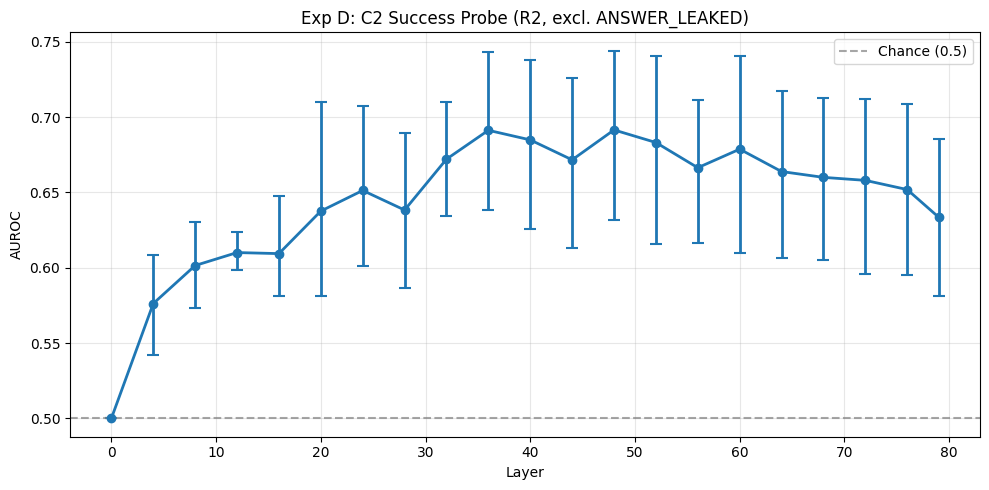

In [5]:
# Probe 1: Predict C2 success from last-token activations
# IMPORTANT: Exclude ANSWER_LEAKED samples -- these trivially succeed at C2
# and would inflate probe AUROC. Only use REASONING_LEGIBLE + ILLEGIBLE.
print("=== Probe: Predict C2 Success (excluding ANSWER_LEAKED) ===")

non_leaked_mask = np.array([
    m['label'] in ('REASONING_LEGIBLE', 'ILLEGIBLE')
    for m in r2_sample_meta
])
non_leaked_labels = r2_labels[non_leaked_mask]

print(f"Non-leaked samples: {non_leaked_mask.sum()} "
      f"(C2 success={non_leaked_labels.sum()}, failure={(1-non_leaked_labels).sum()})")

n_min_class = min(non_leaked_labels.sum(), (1 - non_leaked_labels).sum())
if n_min_class < 5:
    print(f"WARNING: Min class has only {n_min_class} samples -- probe may be unreliable")

c2_success_results = {}
for layer_idx in sorted(r2_last.keys()):
    features = r2_last[layer_idx][non_leaked_mask]
    if n_min_class < 5:
        print(f"  Layer {layer_idx}: skipping (min class={n_min_class})")
        continue
    
    result = train_binary_probe(features, non_leaked_labels, n_splits=min(5, n_min_class))
    c2_success_results[layer_idx] = result
    print(f"  Layer {layer_idx:3d}: AUROC={result['auroc']:.3f} CI={result['auroc_ci']}")

if c2_success_results:
    fig, ax = plot_layer_probe_curve(
        c2_success_results,
        title='Exp D: C2 Success Probe (R2, excl. ANSWER_LEAKED)',
        save_path=str(PHASE2_RESULTS_DIR / 'd_c2_success_probe.png'),
    )
    plt.show()

In [6]:
# Probe 2: Predict C2 success from CoT boundary activations
# Exclude ANSWER_LEAKED (same filter as Probe 1)
print("=== Probe: Predict C2 Success (CoT boundary, excl. ANSWER_LEAKED) ===")

boundary_results = {}
for layer_idx in sorted(r2_boundary.keys()):
    features = r2_boundary[layer_idx][non_leaked_mask]
    if n_min_class < 5:
        continue
    
    result = train_binary_probe(features, non_leaked_labels, n_splits=min(5, n_min_class))
    boundary_results[layer_idx] = result
    print(f"  Layer {layer_idx:3d}: AUROC={result['auroc']:.3f} CI={result['auroc_ci']}")

=== Probe: Predict C2 Success (CoT boundary, excl. ANSWER_LEAKED) ===
  Layer   0: AUROC=0.490 CI=(0.43011453470277, 0.5503103018985371)
  Layer   4: AUROC=0.507 CI=(0.4510210602759622, 0.5831162983712004)
  Layer   8: AUROC=0.505 CI=(0.4469459487498703, 0.5648962547982155)
  Layer  12: AUROC=0.508 CI=(0.4622316630355846, 0.5605555555555556)
  Layer  16: AUROC=0.577 CI=(0.514803195352215, 0.6392640315385413)
  Layer  20: AUROC=0.585 CI=(0.5494093500363108, 0.6359444211017741)
  Layer  24: AUROC=0.595 CI=(0.555132275132275, 0.6431693121693121)
  Layer  28: AUROC=0.612 CI=(0.5925228758169935, 0.6314372860255213)
  Layer  32: AUROC=0.645 CI=(0.6170293598921051, 0.6800058097313)
  Layer  36: AUROC=0.657 CI=(0.6094021164021164, 0.7046298371200332)
  Layer  40: AUROC=0.616 CI=(0.5778571428571428, 0.6542129888992634)
  Layer  44: AUROC=0.634 CI=(0.6049197012138189, 0.6663999377528789)
  Layer  48: AUROC=0.652 CI=(0.613984126984127, 0.6898961510530138)
  Layer  52: AUROC=0.629 CI=(0.5903015873

In [7]:
# Probe 3: Predict legibility class from R2 activations
# (excluding ANSWER_LEAKED)
print("=== Probe: Predict Legibility from R2 Activations ===")

leg_mask = np.array([
    m['label'] in ('REASONING_LEGIBLE', 'ILLEGIBLE')
    for m in r2_sample_meta
])
leg_labels = np.array([
    1 if m['label'] == 'REASONING_LEGIBLE' else 0
    for m in r2_sample_meta
])

print(f"Non-leaked samples: {leg_mask.sum()} "
      f"(legible={leg_labels[leg_mask].sum()}, illegible={(1-leg_labels[leg_mask]).sum()})")

if leg_mask.sum() >= 20:
    legibility_from_reader_results = {}
    for layer_idx in sorted(r2_last.keys()):
        features = r2_last[layer_idx][leg_mask]
        labels = leg_labels[leg_mask]
        
        result = train_binary_probe(features, labels, n_splits=5)
        legibility_from_reader_results[layer_idx] = result
        print(f"  Layer {layer_idx:3d}: AUROC={result['auroc']:.3f} CI={result['auroc_ci']}")
else:
    print("Insufficient non-leaked samples for this analysis")
    legibility_from_reader_results = {}

=== Probe: Predict Legibility from R2 Activations ===
Non-leaked samples: 388 (legible=100, illegible=288)
  Layer   0: AUROC=0.500 CI=(0.5, 0.5)
  Layer   4: AUROC=0.591 CI=(0.532610405323654, 0.6542407743496674)
  Layer   8: AUROC=0.605 CI=(0.5301724137931034, 0.6867053841500301)
  Layer  12: AUROC=0.618 CI=(0.5531397459165155, 0.6890048396854204)
  Layer  16: AUROC=0.642 CI=(0.5827646702964306, 0.7005868118572293)
  Layer  20: AUROC=0.638 CI=(0.5786297640653357, 0.7001300665456744)
  Layer  24: AUROC=0.630 CI=(0.5671143375680581, 0.689425287356322)
  Layer  28: AUROC=0.646 CI=(0.5872958257713249, 0.7074682395644283)
  Layer  32: AUROC=0.672 CI=(0.6213762855414399, 0.7356140350877194)
  Layer  36: AUROC=0.702 CI=(0.6518844525105869, 0.7518753781004234)
  Layer  40: AUROC=0.677 CI=(0.6025922565033273, 0.751140350877193)
  Layer  44: AUROC=0.685 CI=(0.619658197217181, 0.7501845130066546)
  Layer  48: AUROC=0.685 CI=(0.614561403508772, 0.7563339382940109)
  Layer  52: AUROC=0.682 CI=(0.

In [8]:
# Foreignness covariate analysis
foreignness = load_foreignness_scores()

# Get foreignness for each R2 sample
r2_foreignness = []
for m in r2_sample_meta:
    key = (m['sample_id'], m['generator_id'], m['epoch'], 'R2')
    f_score = foreignness.get(key, np.nan)
    r2_foreignness.append(f_score)
r2_foreignness = np.array(r2_foreignness, dtype=float)

valid_f = np.isfinite(r2_foreignness)
print(f"Foreignness available: {valid_f.sum()}/{len(r2_foreignness)}")

if valid_f.sum() >= 20 and c2_success_results:
    # Compare C2 success probe with vs without foreignness
    best_layer = max(c2_success_results, key=lambda k: c2_success_results[k]['auroc'])
    features_base = r2_last[best_layer][valid_f]
    labels_f = r2_labels[valid_f]
    foreignness_f = r2_foreignness[valid_f]
    
    # Without foreignness
    r_no_f = train_binary_probe(features_base, labels_f)
    print(f"Without foreignness: AUROC={r_no_f['auroc']:.3f} CI={r_no_f['auroc_ci']}")
    
    # With foreignness
    features_with_f = np.column_stack([features_base, foreignness_f.reshape(-1, 1)])
    r_with_f = train_binary_probe(features_with_f, labels_f)
    print(f"With foreignness:    AUROC={r_with_f['auroc']:.3f} CI={r_with_f['auroc_ci']}")
    
    # Foreignness only
    r_f_only = train_binary_probe(foreignness_f.reshape(-1, 1), labels_f)
    print(f"Foreignness only:    AUROC={r_f_only['auroc']:.3f} CI={r_f_only['auroc_ci']}")

Foreignness available: 0/666


In [9]:
# Save results
def clean_results(d):
    return {int(k): {kk: vv for kk, vv in v.items() if kk not in ('probe_model', 'scaler')}
            for k, v in d.items()}

output = {
    'c2_success_probe': clean_results(c2_success_results),
    'boundary_probe': clean_results(boundary_results),
    'legibility_from_reader': clean_results(legibility_from_reader_results),
}
with open(PHASE2_RESULTS_DIR / 'reader_analysis_results.json', 'w') as f:
    json.dump(output, f, indent=2, default=str)
print(f"Saved to {PHASE2_RESULTS_DIR / 'reader_analysis_results.json'}")

Saved to /workspace/18-4-2026/experiments/2026/15-4-2026/results/phase2/reader_analysis_results.json
